# Audio Feature Dashboard — Single File Viewer

**Usage:** Change the `WAV_FILE` path in the cell below, then **Run All**.  
The notebook generates a comprehensive acoustic feature dashboard for that recording,  
and saves it as a high-resolution PNG.

---

In [5]:
WAV_FILE = '../KCL/ReadText/HC/ID00_hc_0_0_0.wav'

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display
import parselmouth
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'figure.dpi': 150,
})

In [7]:
# ============================================================
# Load audio & extract all features
# ============================================================
assert os.path.isfile(WAV_FILE), f'File not found: {WAV_FILE}'
fname = os.path.basename(WAV_FILE)

y, sr = librosa.load(WAV_FILE, sr=None)
duration = len(y) / sr
time_axis = np.arange(len(y)) / sr

frame_length = int(sr * 0.025)
hop_length   = int(sr * 0.010)

# RMS Energy
rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
rms_db = 20 * np.log10(rms + 1e-10)
rms_times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop_length)

# Zero-Crossing Rate
zcr = librosa.feature.zero_crossing_rate(y, frame_length=frame_length, hop_length=hop_length)[0]
zcr_times = librosa.frames_to_time(np.arange(len(zcr)), sr=sr, hop_length=hop_length)

# Spectral Centroid
centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hop_length)[0]
centroid_times = librosa.frames_to_time(np.arange(len(centroid)), sr=sr, hop_length=hop_length)

# MFCCs
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=frame_length, hop_length=hop_length)

# F0 via Praat
snd = parselmouth.Sound(WAV_FILE)
pitch = snd.to_pitch(time_step=0.01, pitch_floor=75.0, pitch_ceiling=500.0)
f0_values = pitch.selected_array['frequency']
f0_times  = pitch.xs()
f0_voiced = f0_values.copy()
f0_voiced[f0_voiced == 0] = np.nan
f0_clean = f0_values[f0_values > 0]

# Intensity via Praat
intensity_obj = snd.to_intensity(time_step=0.01, minimum_pitch=75.0)
int_values = intensity_obj.values[0]
int_times  = intensity_obj.xs()

# Mel Spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=hop_length, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)

print(f'Loaded: {fname}  |  {sr} Hz  |  {duration:.2f} s  |  {len(y):,} samples')

Loaded: ID00_hc_0_0_0.wav  |  44100 Hz  |  151.11 s  |  6,664,159 samples


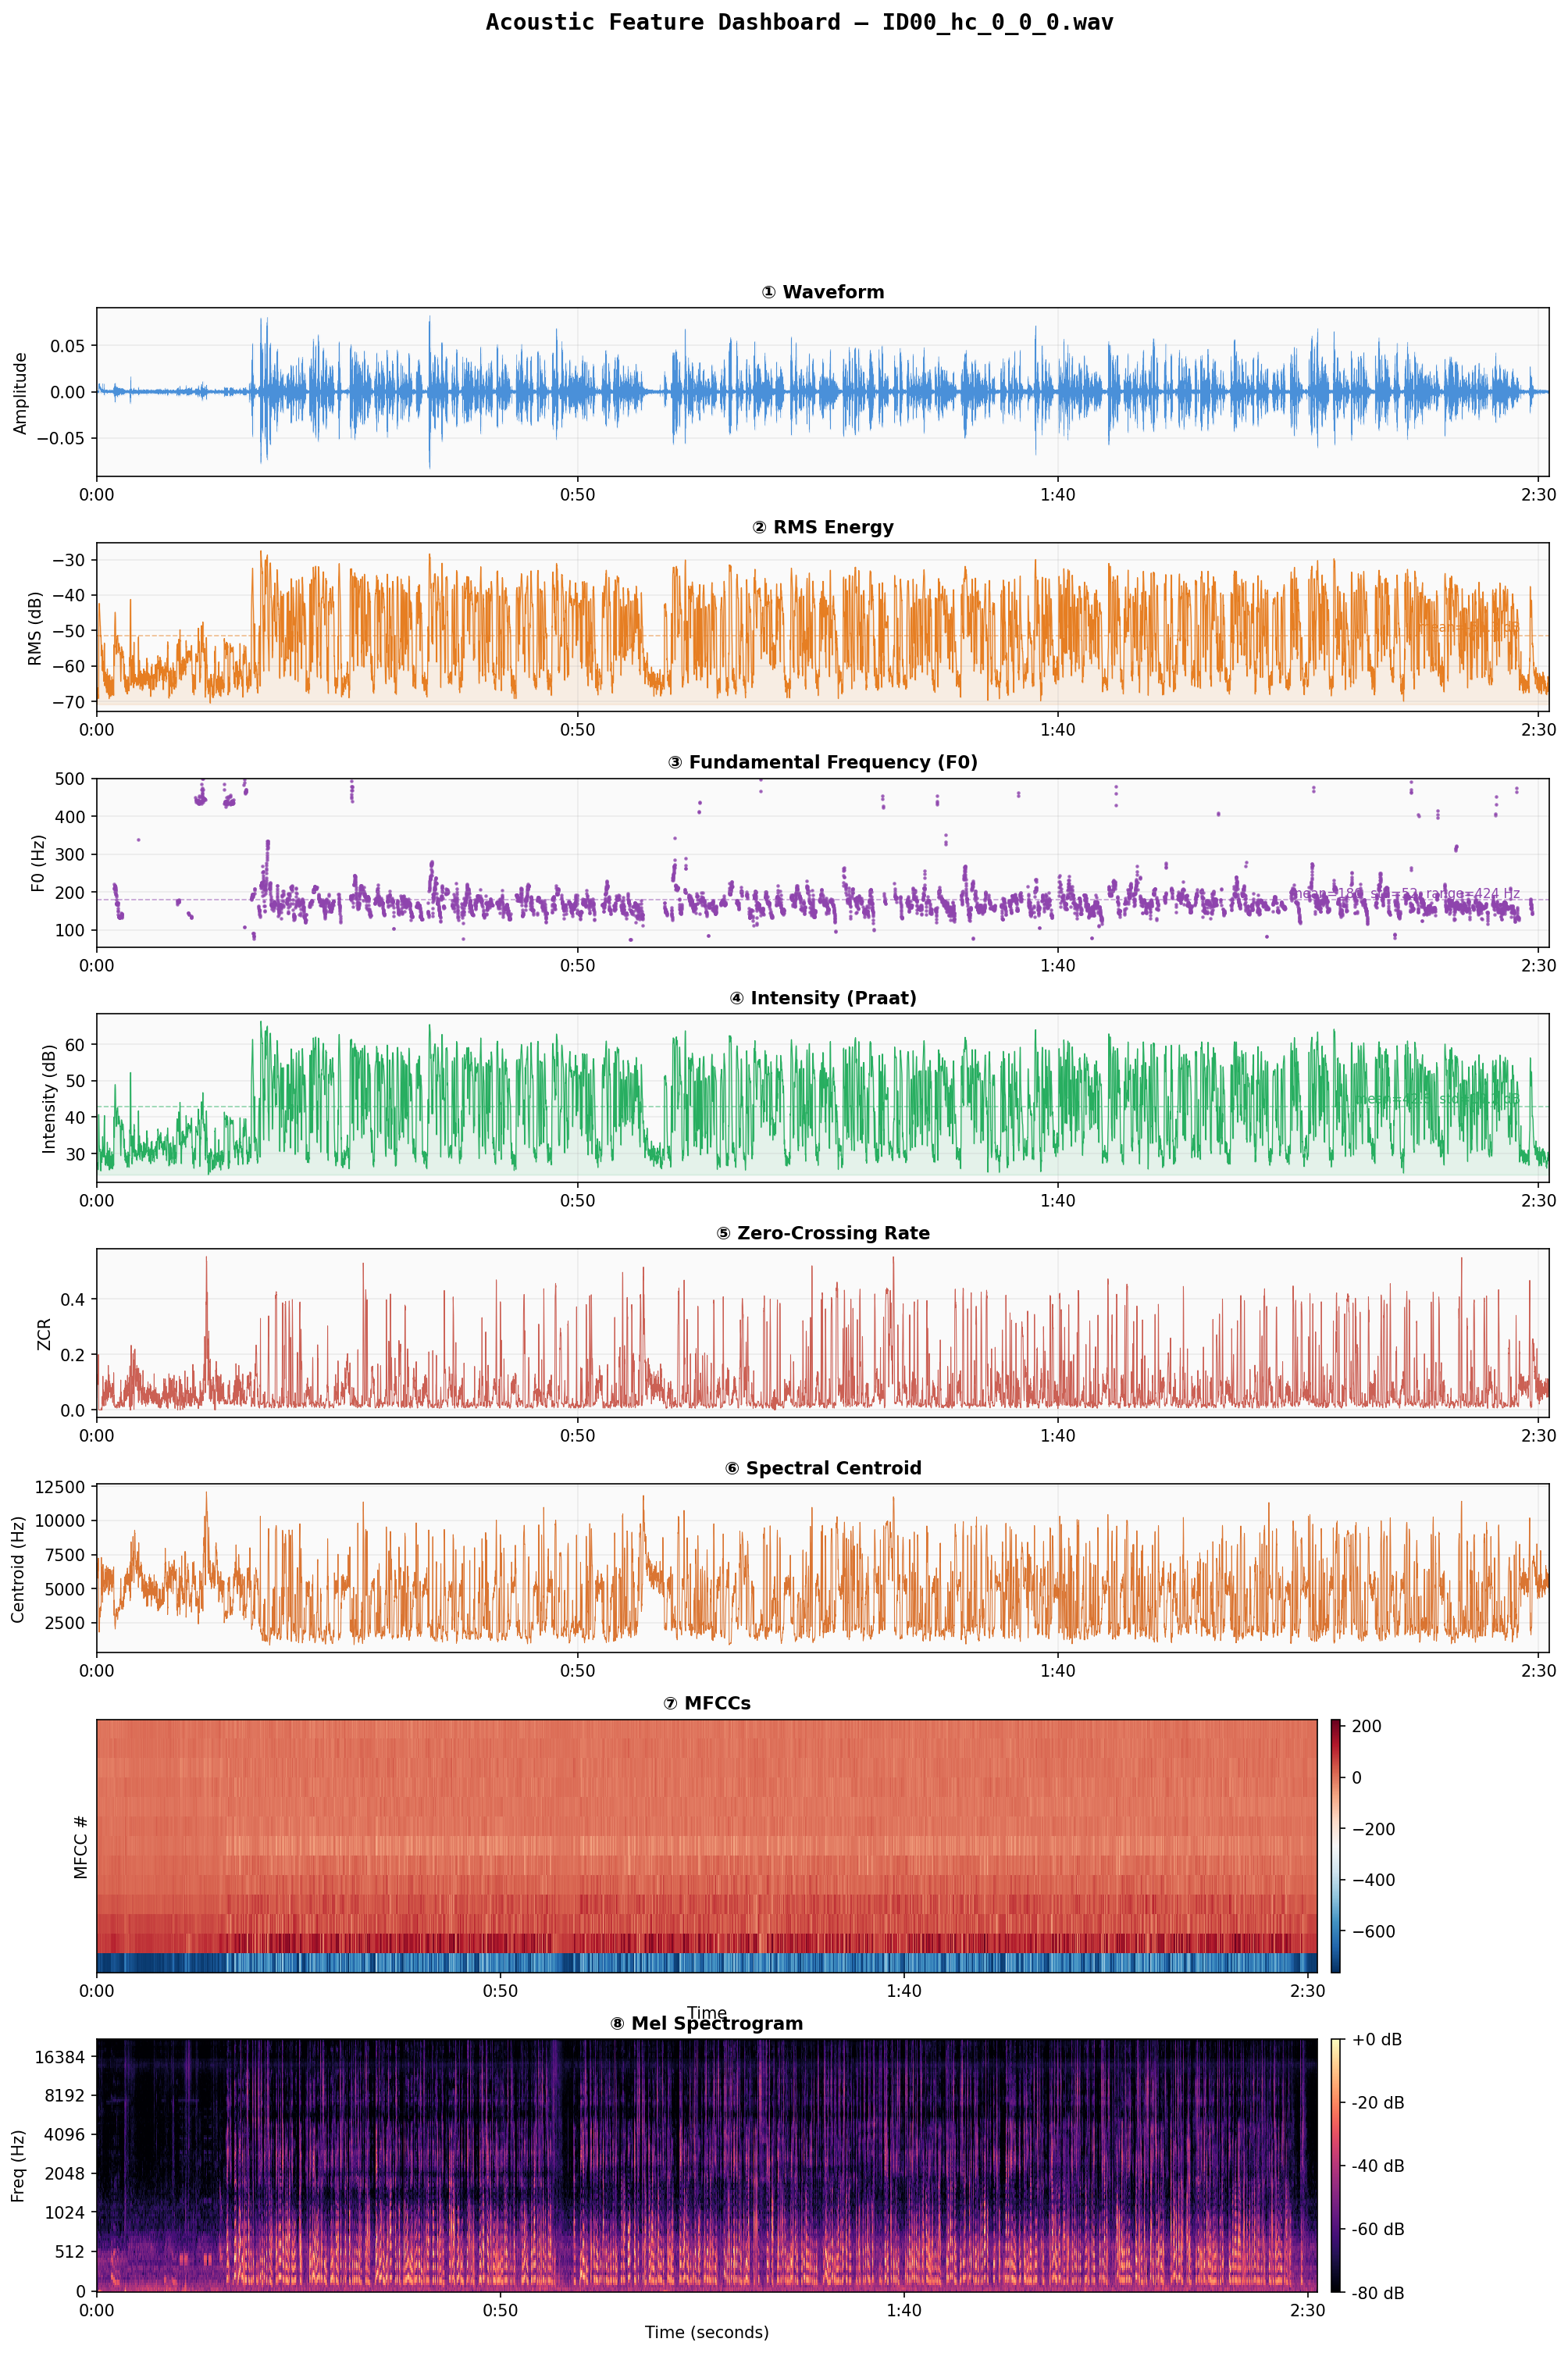

Saved → dashboard_ID00_hc_0_0_0.png


In [8]:
# ============================================================
# Generate the dashboard figure
# ============================================================
C = {'wave': '#4A90D9', 'rms': '#E67E22', 'f0': '#8E44AD',
     'int': '#27AE60', 'zcr': '#C0392B', 'cent': '#D35400', 'bg': '#FAFAFA'}

fig = plt.figure(figsize=(16, 22), facecolor='white')
gs = gridspec.GridSpec(8, 1, height_ratios=[1, 1, 1, 1, 1, 1, 1.5, 1.5], hspace=0.35)
fig.suptitle(f'Acoustic Feature Dashboard — {fname}',
             fontsize=14, fontweight='bold', y=0.995, fontfamily='monospace')

def style_ax(ax, title, ylabel, color, show_xlabel=False):
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_facecolor(C['bg'])
    ax.grid(True, alpha=0.2)
    ax.set_xlim(0, duration)
    if not show_xlabel:
        ax.set_xlabel('')

# 1 — Waveform
ax = fig.add_subplot(gs[0])
ax.plot(time_axis, y, linewidth=0.15, color=C['wave'])
ax.fill_between(time_axis, y, alpha=0.08, color=C['wave'])
style_ax(ax, '① Waveform', 'Amplitude', C['wave'])

# 2 — RMS Energy
ax = fig.add_subplot(gs[1], sharex=fig.axes[0])
ax.plot(rms_times, rms_db, linewidth=0.6, color=C['rms'])
ax.fill_between(rms_times, rms_db, rms_db.min(), alpha=0.1, color=C['rms'])
ax.axhline(rms_db.mean(), color=C['rms'], ls='--', lw=0.8, alpha=0.5)
ax.text(duration*0.98, rms_db.mean()+1, f'mean={rms_db.mean():.1f} dB',
        ha='right', fontsize=8, color=C['rms'])
style_ax(ax, '② RMS Energy', 'RMS (dB)', C['rms'])

# 3 — F0
ax = fig.add_subplot(gs[2], sharex=fig.axes[0])
ax.scatter(f0_times, f0_voiced, s=1.5, color=C['f0'], alpha=0.7)
if len(f0_clean) > 0:
    ax.set_ylim(max(50, f0_clean.min()-20), min(500, f0_clean.max()+30))
    ax.axhline(f0_clean.mean(), color=C['f0'], ls='--', lw=0.8, alpha=0.5)
    ax.text(duration*0.98, f0_clean.mean()+5,
            f'mean={f0_clean.mean():.0f}  std={f0_clean.std():.0f}  range={f0_clean.max()-f0_clean.min():.0f} Hz',
            ha='right', fontsize=8, color=C['f0'])
style_ax(ax, '③ Fundamental Frequency (F0)', 'F0 (Hz)', C['f0'])

# 4 — Intensity
ax = fig.add_subplot(gs[3], sharex=fig.axes[0])
ax.plot(int_times, int_values, linewidth=0.6, color=C['int'])
ax.fill_between(int_times, int_values, int_values.min(), alpha=0.1, color=C['int'])
ax.axhline(int_values.mean(), color=C['int'], ls='--', lw=0.8, alpha=0.5)
ax.text(duration*0.98, int_values.mean()+1,
        f'mean={int_values.mean():.1f}  std={int_values.std():.1f} dB',
        ha='right', fontsize=8, color=C['int'])
style_ax(ax, '④ Intensity (Praat)', 'Intensity (dB)', C['int'])

# 5 — ZCR
ax = fig.add_subplot(gs[4], sharex=fig.axes[0])
ax.plot(zcr_times, zcr, linewidth=0.5, color=C['zcr'], alpha=0.8)
style_ax(ax, '⑤ Zero-Crossing Rate', 'ZCR', C['zcr'])

# 6 — Spectral Centroid
ax = fig.add_subplot(gs[5], sharex=fig.axes[0])
ax.plot(centroid_times, centroid, linewidth=0.5, color=C['cent'], alpha=0.8)
style_ax(ax, '⑥ Spectral Centroid', 'Centroid (Hz)', C['cent'])

# 7 — MFCCs
ax = fig.add_subplot(gs[6], sharex=fig.axes[0])
img = librosa.display.specshow(mfccs, sr=sr, hop_length=hop_length,
                               x_axis='time', ax=ax, cmap='RdBu_r')
ax.set_title('⑦ MFCCs', fontweight='bold')
ax.set_ylabel('MFCC #')
fig.colorbar(img, ax=ax, aspect=30, pad=0.01)

# 8 — Mel Spectrogram
ax = fig.add_subplot(gs[7], sharex=fig.axes[0])
img2 = librosa.display.specshow(S_dB, sr=sr, hop_length=hop_length,
                                x_axis='time', y_axis='mel', ax=ax, cmap='magma')
ax.set_title('⑧ Mel Spectrogram', fontweight='bold')
ax.set_ylabel('Freq (Hz)')
ax.set_xlabel('Time (seconds)')
fig.colorbar(img2, ax=ax, format='%+2.0f dB', aspect=30, pad=0.01)

out_name = f'dashboard_{os.path.splitext(fname)[0]}.png'
plt.savefig(out_name, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {out_name}')

In [ ]:
# ============================================================
# Summary statistics card
# ============================================================
vf = len(f0_clean) / len(f0_values) if len(f0_values) > 0 else 0

print('┌─────────────────────────────────────────────────────────┐')
print(f'│  {fname:<55s} │')
print('├──────────────────────┬──────────────────────────────────┤')
print(f'│  Duration           │ {duration:>8.2f} s                        │')
print(f'│  Sample rate        │ {sr:>8d} Hz                       │')
print('├──────────────────────┼──────────────────────────────────┤')
print(f'│  F0 mean            │ {f0_clean.mean():>8.1f} Hz                       │' if len(f0_clean) else '│  F0 mean            │      N/A                          │')
print(f'│  F0 std             │ {f0_clean.std():>8.1f} Hz                       │' if len(f0_clean) else '│  F0 std             │      N/A                          │')
print(f'│  F0 range           │ {f0_clean.max()-f0_clean.min():>8.1f} Hz                       │' if len(f0_clean) else '│  F0 range           │      N/A                          │')
print(f'│  Voicing fraction   │ {vf:>8.1%}                          │')
print('├──────────────────────┼──────────────────────────────────┤')
print(f'│  RMS mean           │ {rms_db.mean():>8.1f} dB                       │')
print(f'│  RMS std            │ {rms_db.std():>8.1f} dB                       │')
print(f'│  Intensity mean     │ {int_values.mean():>8.1f} dB                       │')
print(f'│  Intensity std      │ {int_values.std():>8.1f} dB                       │')
print('├──────────────────────┼──────────────────────────────────┤')
print(f'│  ZCR mean           │ {zcr.mean():>8.4f}                           │')
print(f'│  Centroid mean      │ {centroid.mean():>8.0f} Hz                       │')
print('└──────────────────────┴──────────────────────────────────┘')